In [23]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

from utils import load_coffee_data

### Dataset

In [5]:
X, Y = load_coffee_data()
print(X.shape, Y.shape)

(200, 2) (200, 1)


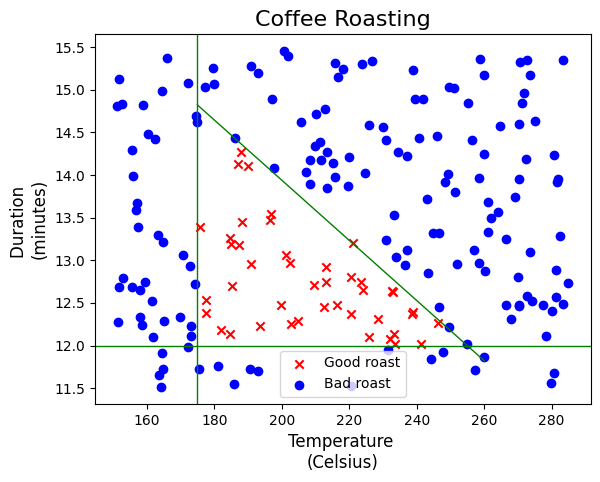

In [14]:
Y_tmp = Y.reshape(-1,)

fig, ax = plt.subplots(1,1,)

ax.scatter(X[Y_tmp==1,0], X[Y_tmp==1,1], marker='x', c='r', label='Good roast')
ax.scatter(X[Y_tmp==0,0], X[Y_tmp==0,1], marker='o', c='b', label='Bad roast')

tr = np.linspace(175,260,50)
ax.plot(tr, (-3/85)*tr + 21, color='g', linewidth=1)
ax.axhline(y=12, color='g', linewidth=1)
ax.axvline(x=175, color='g', linewidth=1)

ax.set_title(f"Coffee Roasting", size=16)
ax.set_xlabel("Temperature \n(Celsius)",size=12)
ax.set_ylabel("Duration \n(minutes)",size=12)
ax.legend()
plt.show()

### Normalize Data
Fitting the weights to the data (back-propagation, covered in next week's lectures) will proceed more quickly if the data is normalized. This is the same procedure you used in Course 1 where features in the data are each normalized to have a similar range. 
The procedure below uses a Keras [normalization layer](https://keras.io/api/layers/preprocessing_layers/numerical/normalization/). It has the following steps:
- create a "Normalization Layer". Note, as applied here, this is not a layer in your model.
- 'adapt' the data. This learns the mean and variance of the data set and saves the values internally.
- normalize the data.  
It is important to apply normalization to any future data that utilizes the learned model.

In [21]:
print(f"Temp Max,Min pre normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Duration Max,Min pre normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")

# Normalization along columns
norm_layer = tf.keras.layers.Normalization(axis=1)
norm_layer.adapt(X) # learns mean, variance
Xn = norm_layer(X)

print(f"Temp Max,Min post normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Duration Max,Min post normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}")

Temp Max,Min pre normalization: 284.99, 151.32
Duration Max,Min pre normalization: 15.45, 11.51
Temp Max,Min post normalization: 1.66, -1.69
Duration Max,Min post normalization: 1.79, -1.70


Tile/copy our data to increase the training set size and reduce the number of training epochs.

In [22]:
Xt = np.tile(Xn,(1000,1))
Yt = np.tile(Y,(1000,1))
print(Xt.shape, Yt.shape)

(200000, 2) (200000, 1)


### Tensorflow Model

#### Model

In [24]:
tf.random.set_seed(1234) # applied to achieve consistent result
model = Sequential(
    [
        tf.keras.Input(shape=(2,)),
        Dense(units=3, activation='sigmoid', name='L1'),
        Dense(units=1, activation='sigmoid', name='L2')
    ]
)

>**Note 1:** The `tf.keras.Input(shape=(2,)),` specifies the expected shape of the input. This allows Tensorflow to size the weights and bias parameters at this point.  This is useful when exploring Tensorflow models. This statement can be omitted in practice and Tensorflow will size the network parameters when the input data is specified in the `model.fit` statement.  
>**Note 2:** Including the sigmoid activation in the final layer is not considered best practice. It would instead be accounted for in the loss which improves numerical stability. This will be described in more detail in a later lab.

The `model.summary()` provides a description of the network:

In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

The parameter counts shown in the summary correspond to the number of elements in the weight and bias arrays as shown below.

In [27]:
L1_num_params = 2 * 3 + 3   # W1 parameters  + b1 parameters
L2_num_params = 3 * 1 + 1   # W2 parameters  + b2 parameters
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params  )

L1 params =  9 , L2 params =  4


Let's examine the weights and biases Tensorflow has instantiated.  The weights $W$ should be of size (number of features in input, number of units in the layer) while the bias $b$ size should match the number of units in the layer:
- In the first layer with 3 units, we expect W to have a size of (2,3) and $b$ should have 3 elements.
- In the second layer with 1 unit, we expect W to have a size of (3,1) and $b$ should have 1 element.

In [35]:
w1, b1 = model.get_layer('L1').get_weights()
w2, b2 = model.get_layer('L2').get_weights()
print(f"w1{w1.shape}: \n {w1} \nb1{b1.shape}: {b1}")
print(f"w1{w2.shape}: \n {w2} \nb1{b2.shape}: {b2}")

w1(2, 3): 
 [[ 14.5056305    0.16808449 -10.989568  ]
 [ 12.105629    10.560947    -0.25752616]] 
b1(3,): [  2.0036135  12.700916  -11.848741 ]
w1(3, 1): 
 [[-47.708347]
 [ 45.46684 ]
 [-55.366642]] 
b1(1,): [-14.12674]


The following statements will be described in detail in Week2. For now:
- The `model.compile` statement defines a loss function and specifies a compile optimization.
- The `model.fit` statement runs gradient descent and fits the weights to the data.

In [36]:
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
)

model.fit(
    Xt,Yt,
    epochs=10
)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 0.0011
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 8.1496e-04
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 6.1910e-04
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 4.7972e-04
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 3.7913e-04
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 3.0561e-04
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 2.5120e-04
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 2.1034e-04
Epoch 9/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - loss: 1.7918e-04
Epoch 10/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - loss: 1.5500e-04


#### Updated Weights
After fitting, the weights have been updated: 

In [37]:
w1, b1 = model.get_layer('L1').get_weights()
w2, b2 = model.get_layer('L2').get_weights()
print(f"w1{w1.shape}: \n {w1} \nb1{b1.shape}: {b1}")
print(f"w1{w2.shape}: \n {w2} \nb1{b2.shape}: {b2}")

w1(2, 3): 
 [[ 16.889217     0.28508478 -11.9497175 ]
 [ 14.013016    11.574565    -0.29572085]] 
b1(3,): [  2.4935696  13.830483  -12.66282  ]
w1(3, 1): 
 [[-73.25042]
 [ 73.76786]
 [-83.65842]] 
b1(1,): [-21.40651]


Next, we will load some saved weights from a previous training run. This is so that this notebook remains robust to changes in Tensorflow over time. Different training runs can produce somewhat different results and the discussion below applies to a particular solution. Feel free to re-run the notebook with this cell commented out to see the difference.

In [39]:
W1 = np.array([
    [-8.94,  0.29, 12.89],
    [-0.17, -7.34, 10.79]] )
b1 = np.array([-9.87, -9.28,  1.01])
W2 = np.array([
    [-31.38],
    [-27.86],
    [-32.79]])
b2 = np.array([15.54])
model.get_layer("L1").set_weights([W1,b1])
model.get_layer("L2").set_weights([W2,b2])

### Predictions

In [40]:
X_test = np.array([
    [200,13.9],  # postive example
    [200,17]  # negative example
])

X_testn = norm_layer(X_test)

predictions = model.predict(X_testn)
print(f"Predictions: \n{predictions}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predictions: 
[[9.625126e-01]
 [3.031606e-08]]


#### Epochs and batches
In the `compile` statement above, the number of `epochs` was set to 10. This specifies that the entire data set should be applied during training 10 times.  During training, you see output describing the progress of training that looks like this:
```
Epoch 1/10
6250/6250 [==============================] - 6s 910us/step - loss: 0.1782
```
The first line, `Epoch 1/10`, describes which epoch the model is currently running. For efficiency, the training data set is broken into 'batches'. The default size of a batch in Tensorflow is 32. There are 200000 examples in our expanded data set or 6250 batches. The notation on the 2nd line `6250/6250 [====` is describing which batch has been executed.

To convert the probabilities to a decision, we apply a threshold:

In [41]:
yhat = (predictions >= 0.5).astype(int)
print(f"decisions = \n{yhat}")

decisions = 
[[1]
 [0]]
